In [1]:
import config
import os, json

import sys
sys.path.append(".")

import utils
import models.datacenter

In [2]:

datacenters = []
for file in os.listdir(config.in_path):
    if "aws_" in file or "gcp_" in file:
        with open(config.in_path + file, "r") as f:
            data = json.load(f)
            provider, location = file.split(".")[0].split("_")
            datacenters.append(
                models.datacenter.Datacenter(
                    provider=provider,
                    location=location,
                    data=data
                )
            )

print("Datacenters loaded: ", len(datacenters))
        

with open(config.in_path + "requests.json", "r") as f:
    requests = json.load(f)

Datacenters loaded:  12


In [4]:
timestamps = utils.get_timestamps(
    init_time= config.dt_i, 
    final_time=config.dt_f, 
    step_duration=config.step
    )

In [5]:

def schedule(baseline):
    discarded_requests = []
    requests_footprints = []
    for timestamp in timestamps:
        for request in requests[utils.date_to_str(timestamp)]:
            request["release_time"] = timestamp
            if baseline:
                datacenters_in_region = [dc for dc in datacenters if dc.location == request["location"]]
            else:
                datacenters_in_region = datacenters
            if not datacenters_in_region:
                discarded_requests.append(request)
            else:
                vm, cost, intesities = None, float("inf"), None
                for dc in datacenters_in_region:
                    # we need to decide in which datacenter and in which VM to place the request
                    _vm, _cost, _footprint = dc.get_best_vm_overall_execution(request, n_nodes=1)
                    if _cost < cost:
                        vm, cost, footprint = _vm, _cost, _footprint
                if vm is None:
                    discarded_requests.append(request)
                else:
                    requests_footprints.append(footprint)
    return requests_footprints
            

In [6]:
out_baseline = schedule(True)
out = schedule(False)

VM: c3.large, expected runtime: 1860.233836863103 approx to 3600.0   
2025-04-08 20:00:00 -> 2025-04-08 21:00:00
VM: c3.xlarge, expected runtime: 3071.723842994063 approx to 3600.0   
2025-04-08 20:00:00 -> 2025-04-08 21:00:00
VM: c3.2xlarge, expected runtime: 61.94382344078957 approx to 3600.0   
2025-04-08 20:00:00 -> 2025-04-08 21:00:00
VM: m3.large, expected runtime: 18253.285277570616 approx to 21600.0   
2025-04-08 20:00:00 -> 2025-04-09 02:00:00
VM: m3.xlarge, expected runtime: 25779.574020440974 approx to 28800.0   
2025-04-08 20:00:00 -> 2025-04-09 04:00:00
VM: m3.2xlarge, expected runtime: 1672.8240373774936 approx to 3600.0   
2025-04-08 20:00:00 -> 2025-04-08 21:00:00
VM: r3.large, expected runtime: 7949.373733119316 approx to 10800.0   
2025-04-08 20:00:00 -> 2025-04-08 23:00:00
VM: r3.xlarge, expected runtime: 12930.388575788977 approx to 14400.0   
2025-04-08 20:00:00 -> 2025-04-09 00:00:00
VM: r3.2xlarge, expected runtime: 11203.174435008475 approx to 14400.0   
2025-04

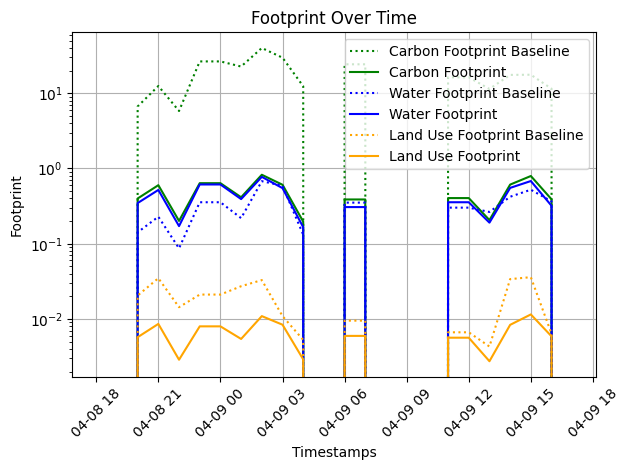

In [28]:

import matplotlib.pyplot as plt

carbon_footprint = []
water_footprint = []
land_use_footprint = []

carbon_footprint_baseline = []
water_footprint_baseline = []
land_use_footprint_baseline = []


for ts in timestamps:
    carbon_sum = 0
    water_sum = 0
    land_use_sum = 0
    for footprint in out:
        if footprint["release_time"] <= ts <= footprint["expected_end_time"]:
            carbon_sum += sum(footprint["carbon"]) * footprint["power_draw"]
            water_sum += sum(footprint["water"]) * footprint["power_draw"]
            land_use_sum += sum(footprint["land_use"]) * footprint["power_draw"]
    carbon_footprint.append(carbon_sum)
    water_footprint.append(water_sum)
    land_use_footprint.append(land_use_sum)

    carbon_sum = 0
    water_sum = 0
    land_use_sum = 0
    for footprint in out_baseline:
        if footprint["release_time"] <= ts <= footprint["expected_end_time"]:
            carbon_sum += sum(footprint["carbon"]) * footprint["power_draw"]
            water_sum += sum(footprint["water"]) * footprint["power_draw"]
            land_use_sum += sum(footprint["land_use"]) * footprint["power_draw"]
    carbon_footprint_baseline.append(carbon_sum)
    water_footprint_baseline.append(water_sum)
    land_use_footprint_baseline.append(land_use_sum)






plt.plot(timestamps, carbon_footprint_baseline, label="Carbon Footprint Baseline", color="green", linestyle=":")
plt.plot(timestamps, carbon_footprint, label="Carbon Footprint", color = "green")

plt.plot(timestamps, water_footprint_baseline, label="Water Footprint Baseline", color="blue", linestyle=":")
plt.plot(timestamps, water_footprint, label="Water Footprint", color="blue")

plt.plot(timestamps, land_use_footprint_baseline, label="Land Use Footprint Baseline", color="orange", linestyle=":")
plt.plot(timestamps, land_use_footprint, label="Land Use Footprint", color="orange")

plt.yscale("log")
plt.xlabel("Timestamps")
plt.ylabel("Footprint")
plt.title("Footprint Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

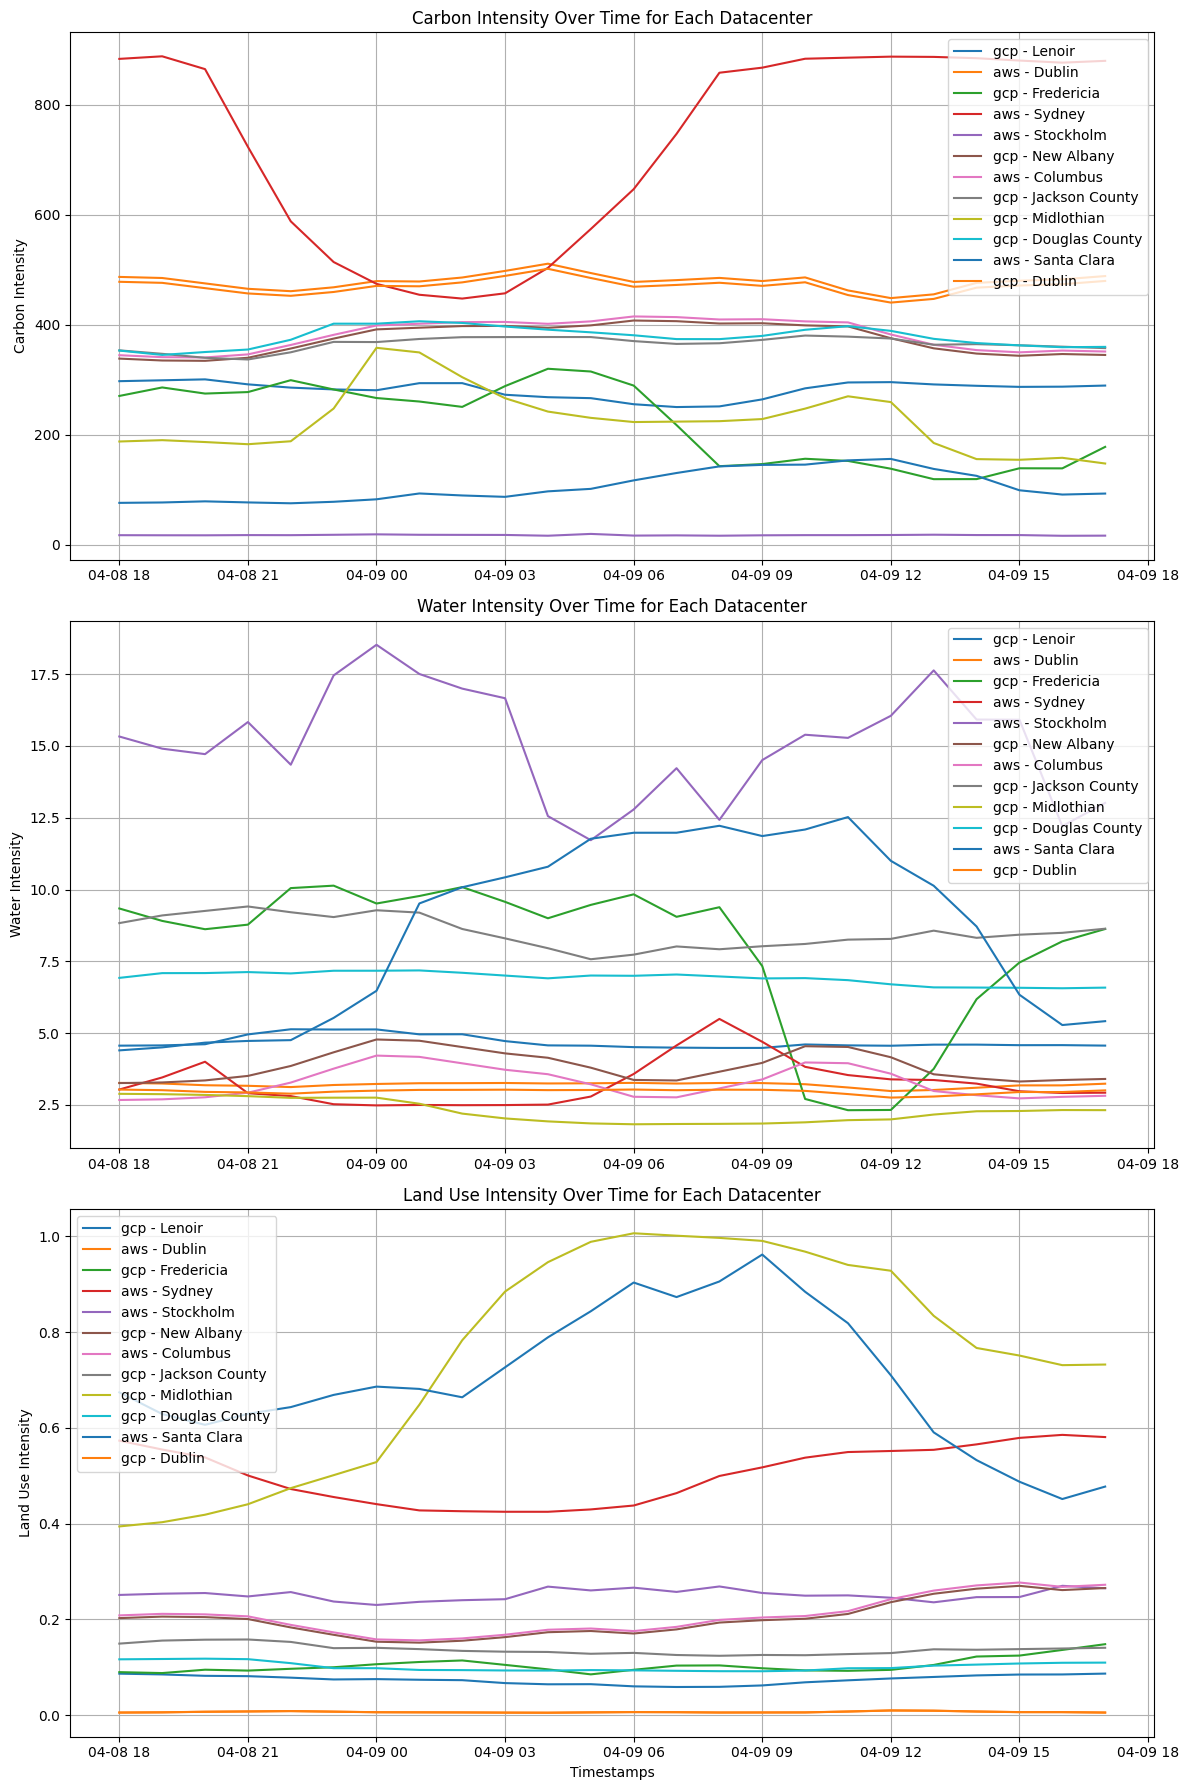